In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [3]:
logs = os.listdir('.')
logs = [l for l in logs if l.endswith('.log')]

In [4]:
'''
|tIoU = 0.10: mAP = 80.59 (%)
|tIoU = 0.20: mAP = 80.22 (%)
|tIoU = 0.30: mAP = 71.75 (%)
|tIoU = 0.40: mAP = 58.37 (%)
|tIoU = 0.50: mAP = 35.62 (%)
|tIoU = 0.60: mAP = 22.38 (%)
|tIoU = 0.70: mAP = 5.16 (%)
Avearge mAP: 50.58 (%)
All done! Total time: 27.26 sec
'''

def read_log(log):
    with open(log, 'r') as f:
        lines = f.readlines()
    mAPs = []
    for line in lines:
        if 'mAP' in line:
            mAPs.append(float(line.split(' ')[-2]))
    return mAPs

In [5]:
read_log(logs[0])

[82.46, 82.46, 73.88, 59.94, 34.86, 22.55, 5.28, 51.63]

In [11]:
# pd
data = []
for log in tqdm(logs):
    mAPs = read_log(log)
    data.append([log] + mAPs)
data

100%|██████████| 44/44 [00:00<00:00, 13362.49it/s]


[['epoch_029_0.81277.pth.tar.log',
  82.46,
  82.46,
  73.88,
  59.94,
  34.86,
  22.55,
  5.28,
  51.63],
 ['epoch_023_0.82264.pth.tar.log',
  83.88,
  82.81,
  74.05,
  57.19,
  35.12,
  21.87,
  5.16,
  51.44],
 ['epoch_012_0.81696.pth.tar.log',
  82.33,
  80.6,
  75.36,
  57.49,
  35.47,
  22.54,
  8.34,
  51.73],
 ['epoch_007_0.82101.pth.tar.log',
  84.15,
  84.15,
  79.88,
  57.25,
  37.84,
  19.38,
  7.56,
  52.89],
 ['epoch_011_0.81357.pth.tar.log',
  82.77,
  80.89,
  76.1,
  55.37,
  33.86,
  22.23,
  5.97,
  51.03],
 ['epoch_027_0.81360.pth.tar.log',
  82.96,
  81.88,
  74.02,
  59.68,
  36.18,
  22.24,
  5.47,
  51.78],
 ['epoch_006_0.81519.pth.tar.log',
  84.92,
  84.92,
  81.11,
  57.46,
  39.36,
  22.4,
  8.91,
  54.16],
 ['epoch_032_0.81846.pth.tar.log',
  81.78,
  81.7,
  73.39,
  58.7,
  33.98,
  22.23,
  5.42,
  51.03],
 ['epoch_047_0.81895.pth.tar.log',
  80.72,
  80.35,
  71.99,
  58.47,
  35.65,
  22.33,
  5.12,
  50.66],
 ['epoch_019_0.82098.pth.tar.log',
  82.67

In [12]:
for d in data:
    if len(d) != 9:
        print(d)
# data = sorted(data, key=lambda x: x['log'].split(".pth")[0].split("_")[-1])
df = pd.DataFrame(data, columns=['log',  'mAP_0.1', 'mAP_0.2', 'mAP_0.3', 'mAP_0.4', 'mAP_0.5', 'mAP_0.6', 'mAP_0.7','mean_mAP'])
# sort by mean_mAP
df = df.sort_values(by='log', ascending=False)
# df = df.sort_values(by='mean_mAP', ascending=False)
df

,log,mAP_0.1,mAP_0.2,mAP_0.3,mAP_0.4,mAP_0.5,mAP_0.6,mAP_0.7,mean_mAP
20,epoch_049_0.81844.pth.tar.log,80.59,80.22,71.75,58.37,35.62,22.38,5.16,50.58
32,epoch_048_0.81876.pth.tar.log,80.61,80.23,71.86,58.40,35.67,22.37,5.13,50.61
8,epoch_047_0.81895.pth.tar.log,80.72,80.35,71.99,58.47,35.65,22.33,5.12,50.66
43,epoch_046_0.81861.pth.tar.log,80.75,80.39,71.92,58.33,35.33,22.40,5.21,50.62
33,epoch_045_0.81865.pth.tar.log,80.79,80.45,71.94,58.39,35.43,22.46,5.15,50.66
11,epoch_044_0.81879.pth.tar.log,80.63,80.19,71.73,58.23,35.12,22.22,5.15,50.47
13,epoch_043_0.81832.pth.tar.log,80.86,80.48,71.75,58.31,34.48,22.17,5.10,50.45
14,epoch_042_0.81710.pth.tar.log,80.48,80.23,71.43,57.98,34.95,21.68,5.03,50.25
12,epoch_041_0.81635.pth.tar.log,80.65,80.18,71.34,58.00,34.75,21.52,4.94,50.20
17,epoch_040_0.81570.pth.tar.log,80.88,80.38,71.63,58.22,34.79,21.91,5.11,50.42


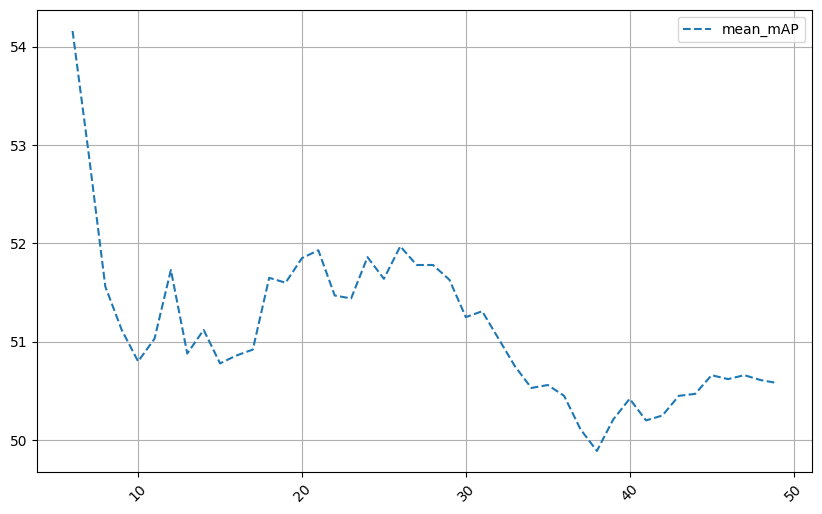

In [10]:
# plot curve
plt.figure(figsize=(10, 6))
# x: epoch, y: mAP
# get epoch from log name: epoch_x_performance.pth.tar.log
df['epoch'] = df['log'].apply(lambda x: int(x.split('_')[1]))
df = df.sort_values(by='epoch')
for i in range(1, 9):
    plt.plot()
plt.plot(df['epoch'], df['mean_mAP'], label='mean_mAP', linestyle='--')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()


In [8]:
df.to_csv('mAPs.csv', index=False)